# Pitch Modulation

Vibrato modulates the instantaneous pitch of a signal by sinusoidally sweeping the read position of a short delay line. The read pointer advances by `1 + depth · sin(2π · rate · t)` samples per output sample, creating a continuously varying delay that shifts the playback speed — and therefore the pitch — up and down at `rate` Hz.

| Function | Description |
| --- | --- |
| `vibrato` | Pitch modulation via sinusoidally varying fractional delay. `rate` sets the LFO frequency (Hz); `depth_samples` sets the peak deviation of the delay (larger = wider pitch swing). Internally delegates to `fractional_delay_line` for smooth sub-sample interpolation. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.generators import generate_sine
from python.modulator import vibrato

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

Vibrato applied to a 440 Hz sine over 50 ms.

**2 × 3 grid:**

**Top row — three LFO rates (4 / 6 / 8 Hz), depth = 1 sample:**
- Each column shows the vibrated waveform vs the dry reference
- Higher rate → faster pitch oscillation; cycle-to-cycle phase variation increases
- At depth = 1 sample the frequency deviation is small (< 1 %), giving a subtle classical vibrato

**Bottom row — three LFO depths (1 / 2 / 4 samples), rate = 6 Hz:**
- Deeper depth → wider instantaneous pitch swing; more visible phase variation in the waveform
- At depth = 4 samples the vibrato is perceptually wide (≈ ±2 % frequency deviation at 440 Hz)
- Very large depths introduce harmonic distortion because the Doppler effect from delay modulation becomes non-linear

The relationship between `depth_samples` and the audible pitch deviation in cents is: deviation ≈ 1200 · log₂(1 + depth · 2π · rate / freq).


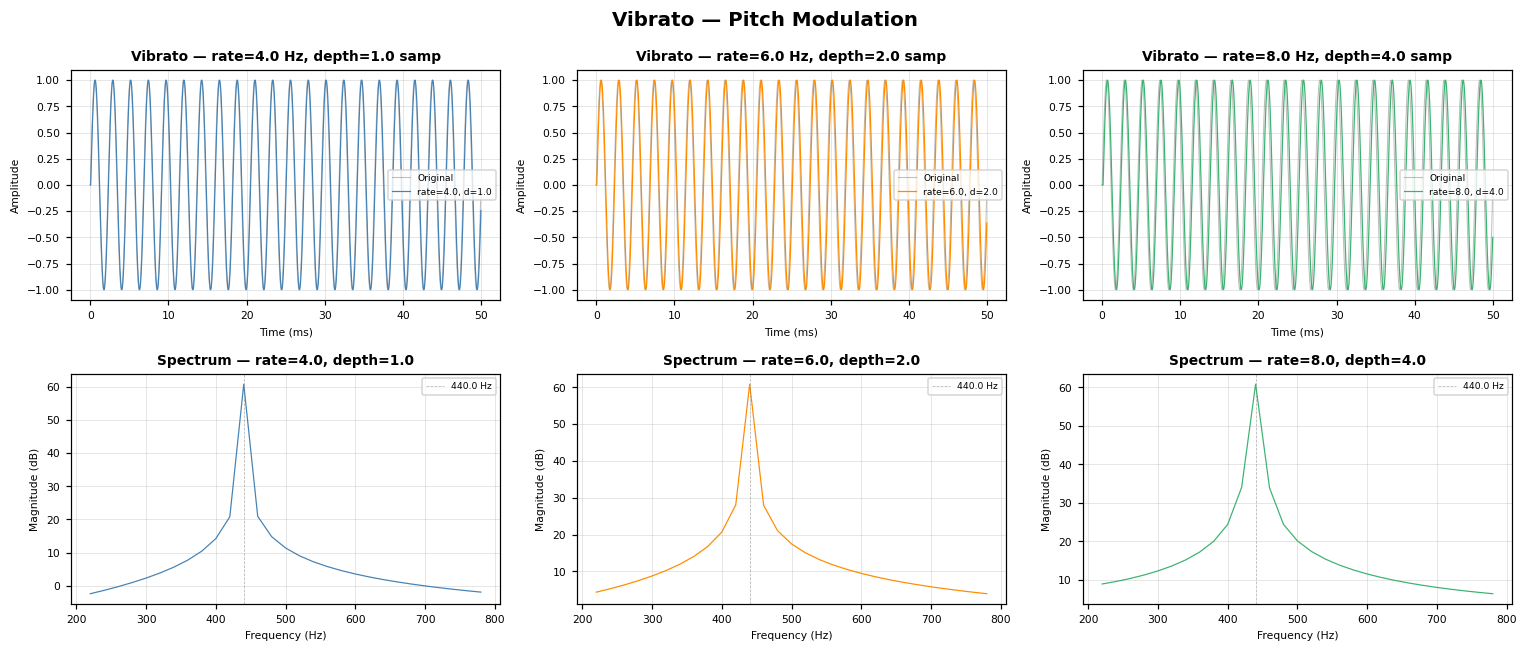

In [2]:
FS = 44100
FREQ = 440.0
DURATION = 0.05

_, sig = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
t_ms = np.arange(len(sig)) / FS * 1000

RATES = [4.0, 6.0, 8.0]
DEPTHS = [1.0, 2.0, 4.0]
COLORS = ["steelblue", "darkorange", "mediumseagreen"]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))

for col, (rate, depth, color) in enumerate(zip(RATES, DEPTHS, COLORS)):
    vib = vibrato(sig, rate=rate, depth_samples=depth, fs=FS)
    # Trim to same length (vibrato may pad internally)
    n = min(len(sig), len(vib))
    axes[0, col].plot(t_ms[:n], sig[:n], linewidth=0.7, color="gray", alpha=0.5, label="Original")
    axes[0, col].plot(t_ms[:n], vib[:n], linewidth=0.8, color=color, label=f"rate={rate}, d={depth}")
    axes[0, col].set_title(f"Vibrato — rate={rate} Hz, depth={depth} samp", fontsize=9, fontweight="bold")
    axes[0, col].set_xlabel("Time (ms)", fontsize=7)
    axes[0, col].set_ylabel("Amplitude", fontsize=7)
    axes[0, col].legend(fontsize=6)
    axes[0, col].tick_params(labelsize=7)
    axes[0, col].grid(True, linewidth=0.4, alpha=0.5)

# Spectrum for one case
for col, (rate, depth, color) in enumerate(zip(RATES, DEPTHS, COLORS)):
    vib = vibrato(sig, rate=rate, depth_samples=depth, fs=FS)
    n = min(len(sig), len(vib))
    freqs = np.fft.rfftfreq(n, d=1.0 / FS)
    db = 20 * np.log10(np.abs(np.fft.rfft(vib[:n])) + 1e-12)
    mask = (freqs > 200) & (freqs < 800)
    axes[1, col].plot(freqs[mask], db[mask], linewidth=0.8, color=color)
    axes[1, col].axvline(FREQ, color="gray", linewidth=0.5, linestyle="--", alpha=0.6, label=f"{FREQ} Hz")
    axes[1, col].set_title(f"Spectrum — rate={rate}, depth={depth}", fontsize=9, fontweight="bold")
    axes[1, col].set_xlabel("Frequency (Hz)", fontsize=7)
    axes[1, col].set_ylabel("Magnitude (dB)", fontsize=7)
    axes[1, col].legend(fontsize=6)
    axes[1, col].tick_params(labelsize=7)
    axes[1, col].grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("Vibrato — Pitch Modulation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Audio Examples

Vibrato is periodic pitch modulation via a fractional delay LFO. Slow and shallow sounds like a vocalist; fast and deep sounds exaggerated.


In [3]:
from IPython.display import Audio, display

DUR_A     = 2.0
_, sig_a  = generate_sine(freq=440.0, fs=FS, duration=DUR_A)

vib_sub  = vibrato(sig_a, rate=4.0, depth_samples=2.0, fs=FS)   # subtle
vib_deep = vibrato(sig_a, rate=7.0, depth_samples=8.0, fs=FS)   # deep

def norm(x): return x / np.max(np.abs(x)) * 0.7

print("Dry sine at 440 Hz")
display(Audio(norm(sig_a), rate=FS))
print("Vibrato — 4 Hz rate, ±2 sample depth (subtle, vocal-like)")
display(Audio(norm(vib_sub), rate=FS))
print("Vibrato — 7 Hz rate, ±8 sample depth (deep pitch wobble)")
display(Audio(norm(vib_deep), rate=FS))

Dry sine at 440 Hz


Vibrato — 4 Hz rate, ±2 sample depth (subtle, vocal-like)


Vibrato — 7 Hz rate, ±8 sample depth (deep pitch wobble)
